In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

print("\nEnvironment is ready!")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\user\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\user\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\user\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\user\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\user\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\user\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\user\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\user\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [ ]:
dataset_url = (
    "https://raw.githubusercontent.com/"
    "nshomron/covidpred/master/data/"
    "corona_tested_individuals_ver_006.english.csv.zip"
)

try:
    df = pd.read_csv(
        dataset_url,
        compression="zip",
        low_memory=False
    )

    print("Dataset loaded successfully!")
    print("Dataset shape:", df.shape)

except Exception as error:
    print("Failed to load the dataset.")
    print("Error:", error)

Dataset loaded successfully!
Dataset shape: (278848, 10)


In [ ]:
display(df.head())

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [ ]:
print("Column names:")

for column in df.columns:
    print("-", column)

Column names:
- test_date
- cough
- fever
- sore_throat
- shortness_of_breath
- head_ache
- corona_result
- age_60_and_above
- gender
- test_indication


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  str    
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  str    
 7   age_60_and_above     151528 non-null  str    
 8   gender               259285 non-null  str    
 9   test_indication      278848 non-null  str    
dtypes: float64(5), str(5)
memory usage: 29.2 MB


In [ ]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

display(
    missing_table.sort_values(
        by="Missing Values",
        ascending=False
    )
)

,Missing Values,Missing Percentage (%)
age_60_and_above,127320,45.66
gender,19563,7.02
fever,252,0.09
cough,252,0.09
head_ache,1,0.00
sore_throat,1,0.00
shortness_of_breath,1,0.00
test_date,0,0.00
corona_result,0,0.00
test_indication,0,0.00


In [ ]:
print("Corona result distribution:")
print(df["corona_result"].value_counts(dropna=False))

Corona result distribution:
corona_result
negative    260227
positive     14729
other         3892
Name: count, dtype: int64


In [ ]:
categorical_columns = [
    "age_60_and_above",
    "gender",
    "test_indication"
]

for column in categorical_columns:
    print(f"\nColumn: {column}")
    print(df[column].value_counts(dropna=False))


Column: age_60_and_above
age_60_and_above
NaN    127320
No     125703
Yes     25825
Name: count, dtype: int64

Column: gender
gender
female    130158
male      129127
NaN        19563
Name: count, dtype: int64

Column: test_indication
test_indication
Other                     242741
Abroad                     25468
Contact with confirmed     10639
Name: count, dtype: int64


In [ ]:
clean_df = df.copy()

print("Original dataset shape:", clean_df.shape)

Original dataset shape: (278848, 10)


In [ ]:
text_columns = [
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
]

for column in text_columns:
    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

print("Text values standardized successfully!")

Text values standardized successfully!


In [ ]:
clean_df = clean_df[
    clean_df["corona_result"].isin([
        "positive",
        "negative"
    ])
].copy()

print("Records after removing 'other':", len(clean_df))

print("\nRemaining target values:")
print(clean_df["corona_result"].value_counts())

Records after removing 'other': 274956

Remaining target values:
corona_result
negative    260227
positive     14729
Name: count, dtype: int64[pyarrow]


In [ ]:
clean_df["target"] = clean_df["corona_result"].map({
    "negative": 0,
    "positive": 1
})

print(clean_df[[
    "corona_result",
    "target"
]].head(10))

  corona_result  target
0      negative       0
1      negative       0
2      negative       0
3      negative       0
4      negative       0
5      negative       0
6      negative       0
7      negative       0
8      negative       0
9      negative       0


In [ ]:
categorical_columns = [
    "age_60_and_above",
    "gender",
    "test_indication"
]

clean_df[categorical_columns] = (
    clean_df[categorical_columns]
    .fillna("unknown")
)

print("Categorical missing values handled!")

Categorical missing values handled!


In [ ]:
symptom_columns = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
]

for column in symptom_columns:
    # Make sure the values are numeric
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

    # Find the most frequently occurring value
    most_common_value = clean_df[column].mode()[0]

    # Fill missing values
    clean_df[column] = (
        clean_df[column]
        .fillna(most_common_value)
        .astype(int)
    )

    print(
        column,
        "filled with:",
        most_common_value
    )

cough filled with: 0.0
fever filled with: 0.0
sore_throat filled with: 0.0
shortness_of_breath filled with: 0.0
head_ache filled with: 0.0


In [ ]:
clean_df = clean_df.drop(
    columns=[
        "test_date",
        "corona_result"
    ]
)

print("Unused columns removed!")

Unused columns removed!


In [ ]:
print("Cleaned dataset shape:", clean_df.shape)

print("\nMissing values after preprocessing:")
print(clean_df.isna().sum())

print("\nTarget distribution:")
print(clean_df["target"].value_counts())

display(clean_df.head())

Cleaned dataset shape: (274956, 9)

Missing values after preprocessing:
cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
age_60_and_above       0
gender                 0
test_indication        0
target                 0
dtype: int64

Target distribution:
target
0    260227
1     14729
Name: count, dtype: int64


,cough,fever,sore_throat,shortness_of_breath,head_ache,age_60_and_above,gender,test_indication,target
0,0,0,0,0,0,unknown,female,other,0
1,1,0,0,0,0,unknown,female,other,0
2,0,1,0,0,0,unknown,male,other,0
3,1,0,0,0,0,unknown,female,other,0
4,1,0,0,0,0,unknown,male,other,0


In [ ]:
# X contains the input features
X = clean_df.drop(columns=["target"])

# y contains the correct answer
y = clean_df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nInput features:")
print(X.columns.tolist())

X shape: (274956, 8)
y shape: (274956,)

Input features:
['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 'age_60_and_above', 'gender', 'test_indication']


In [ ]:
class_distribution = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage (%)": (
        y.value_counts(normalize=True) * 100
    ).round(2)
})

class_distribution.index = [
    "Negative (0)",
    "Positive (1)"
]

display(class_distribution)

,Count,Percentage (%)
Negative (0),260227,94.64
Positive (1),14729,5.36


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (219964, 8)
Testing feature shape: (54992, 8)
Training target shape: (219964,)
Testing target shape: (54992,)


In [ ]:
print("Training target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training target distribution:
target
0    94.64
1     5.36
Name: proportion, dtype: float64

Testing target distribution:
target
0    94.64
1     5.36
Name: proportion, dtype: float64


In [ ]:
symptom_features = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
]

categorical_features = [
    "age_60_and_above",
    "gender",
    "test_indication"
]

print("Symptom features:", symptom_features)
print("Categorical features:", categorical_features)

Symptom features: ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache']
Categorical features: ['age_60_and_above', 'gender', 'test_indication']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "symptoms",
            "passthrough",
            symptom_features
        ),
        (
            "categories",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print(
    "Encoded training shape:",
    X_train_encoded.shape
)

print(
    "Encoded testing shape:",
    X_test_encoded.shape
)

Encoded training shape: (219964, 14)
Encoded testing shape: (54992, 14)


In [ ]:
encoded_feature_names = (
    preprocessor.get_feature_names_out()
)

print("Total encoded features:", len(encoded_feature_names))

for feature in encoded_feature_names:
    print("-", feature)

Total encoded features: 14
- symptoms__cough
- symptoms__fever
- symptoms__sore_throat
- symptoms__shortness_of_breath
- symptoms__head_ache
- categories__age_60_and_above_no
- categories__age_60_and_above_unknown
- categories__age_60_and_above_yes
- categories__gender_female
- categories__gender_male
- categories__gender_unknown
- categories__test_indication_abroad
- categories__test_indication_contact with confirmed
- categories__test_indication_other


    ## Part 6: Classification Model Development

### 6.1 Logistic Regression

Logistic Regression is used to classify COVID-19 test results as positive or negative. Class weighting is applied because the dataset contains significantly more negative cases than positive cases.

In [ ]:
from sklearn.linear_model import LogisticRegression
import time

print("Logistic Regression imported successfully!")

Logistic Regression imported successfully!


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("Logistic Regression model created!")

Logistic Regression model created!


In [ ]:
start_time = time.time()

logistic_model.fit(
    X_train_encoded,
    y_train
)

logistic_training_time = (
    time.time() - start_time
)

print("Training completed!")
print(
    f"Training time: "
    f"{logistic_training_time:.2f} seconds"
)

Training completed!
Training time: 0.28 seconds


In [ ]:
logistic_predictions = logistic_model.predict(
    X_test_encoded
)

print("Prediction completed!")
print(
    "Number of predictions:",
    len(logistic_predictions)
)

print(
    "First 20 predictions:",
    logistic_predictions[:20]
)

Prediction completed!
Number of predictions: 54992
First 20 predictions: [1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0]


#### Logistic Regression Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

print("Logistic Regression Results")
print("--------------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-score : {logistic_f1:.4f}")

Logistic Regression Results
--------------------------------
Accuracy : 0.9276
Precision: 0.4039
Recall   : 0.7393
F1-score : 0.5224


In [ ]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative     0.9845    0.9382    0.9608     52046
    Positive     0.4039    0.7393    0.5224      2946

    accuracy                         0.9276     54992
   macro avg     0.6942    0.8388    0.7416     54992
weighted avg     0.9534    0.9276    0.9373     54992



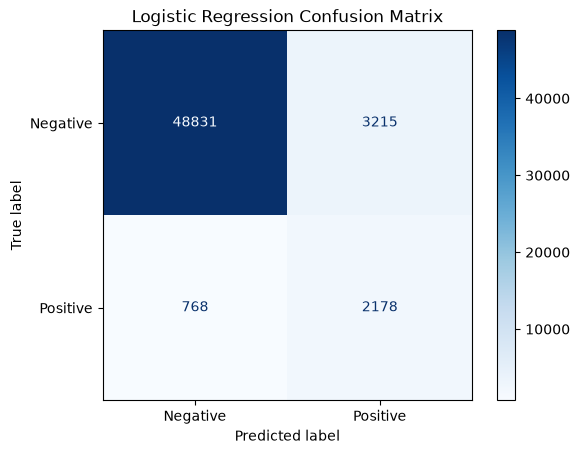

In [ ]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=[
        "Negative",
        "Positive"
    ],
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [ ]:
logistic_result = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1-score": logistic_f1,
    "Training Time": logistic_training_time
}

print(logistic_result)

{'Model': 'Logistic Regression', 'Accuracy': 0.927571283095723, 'Precision': 0.40385685147413314, 'Recall': 0.7393075356415478, 'F1-score': 0.5223647919414798, 'Training Time': 0.28142309188842773}


#### Interpretation of Logistic Regression Results

The Logistic Regression model achieved an accuracy of 92.76%, precision of 40.39%, recall of 73.93%, and F1-score of 52.24%. The model correctly identified 2,178 out of 2,946 positive cases, giving it a relatively strong recall. However, it also incorrectly classified 3,215 negative cases as positive, resulting in lower precision. This shows that applying balanced class weights helped the model identify more positive cases, but increased the number of false-positive predictions. Therefore, accuracy alone is insufficient for evaluating this imbalanced dataset, and recall and F1-score must also be considered.

In [ ]:
import joblib
from pathlib import Path

model_bundle = {
    "model": logistic_model,
    "preprocessor": preprocessor
}

model_path = (
    Path.cwd() / "logistic_bundle.pkl"
)

joblib.dump(
    model_bundle,
    model_path
)

print("Model and preprocessor saved!")
print("Saved location:", model_path)

Model and preprocessor saved!
Saved location: c:\Users\Leon\Documents\GitHub\COVID19_ML_Project\logistic_bundle.pkl


### 6.2 Model 2: Random Forest

Random Forest is the second supervised classification model. It combines multiple decision trees and determines the final classification result using the predictions produced by the trees.

In [ ]:
print("Training features:", X_train_encoded.shape)
print("Testing features:", X_test_encoded.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (219964, 14)
Testing features: (54992, 14)
Training target: (219964,)
Testing target: (54992,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created!")

Random Forest model created!


In [ ]:
start_time = time.time()

random_forest_model.fit(
    X_train_encoded,
    y_train
)

random_forest_training_time = (
    time.time() - start_time
)

print("Random Forest training completed!")

print(
    f"Training time: "
    f"{random_forest_training_time:.2f} seconds"
)

Random Forest training completed!
Training time: 7.64 seconds


In [ ]:
random_forest_predictions = (
    random_forest_model.predict(
        X_test_encoded
    )
)

print("Prediction completed!")

print(
    "Number of predictions:",
    len(random_forest_predictions)
)

print(
    "First 20 predictions:",
    random_forest_predictions[:20]
)

Prediction completed!
Number of predictions: 54992
First 20 predictions: [1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0]


In [ ]:
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions,
    zero_division=0
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions,
    zero_division=0
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions,
    zero_division=0
)

print("Random Forest Results")
print("--------------------------------")

print(
    f"Accuracy : "
    f"{random_forest_accuracy:.4f}"
)

print(
    f"Precision: "
    f"{random_forest_precision:.4f}"
)

print(
    f"Recall   : "
    f"{random_forest_recall:.4f}"
)

print(
    f"F1-score : "
    f"{random_forest_f1:.4f}"
)

Random Forest Results
--------------------------------
Accuracy : 0.9282
Precision: 0.4102
Recall   : 0.7756
F1-score : 0.5366


In [ ]:
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative     0.9866    0.9369    0.9611     52046
    Positive     0.4102    0.7756    0.5366      2946

    accuracy                         0.9282     54992
   macro avg     0.6984    0.8563    0.7489     54992
weighted avg     0.9557    0.9282    0.9384     54992



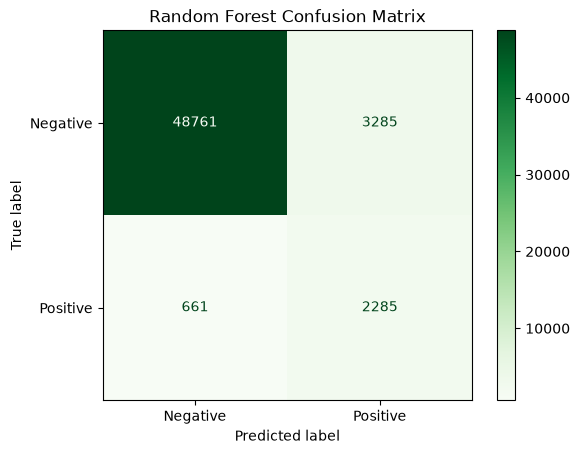

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_predictions,
    display_labels=[
        "Negative",
        "Positive"
    ],
    cmap="Greens",
    values_format="d"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [ ]:
random_forest_result = {
    "Model": "Random Forest",
    "Accuracy": random_forest_accuracy,
    "Precision": random_forest_precision,
    "Recall": random_forest_recall,
    "F1-score": random_forest_f1,
    "Training Time": random_forest_training_time
}

print(random_forest_result)

{'Model': 'Random Forest', 'Accuracy': 0.9282441082339249, 'Precision': 0.4102333931777379, 'Recall': 0.7756279701289884, 'F1-score': 0.536636918741193, 'Training Time': 7.636868715286255}


#### Interpretation of Random Forest Results

The Random Forest model achieved an accuracy of 92.82%, precision of 41.02%, recall of 77.56%, and F1-score of 53.66%. It correctly identified 2,285 positive cases and missed 661 positive cases. Compared with Logistic Regression, Random Forest produced higher recall and F1-score, showing better ability to detect positive cases. However, it required a longer training time and still produced 3,285 false-positive predictions.

### 6.3 Model 3: Linear Support Vector Machine

Linear SVM identifies a decision boundary that separates positive and negative COVID-19 cases. Balanced class weights are applied because positive cases form a small proportion of the dataset.

In [ ]:
from sklearn.svm import LinearSVC
import time

linear_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=10000,
    random_state=42
)

print("Linear SVM model created!")

Linear SVM model created!


In [ ]:
start_time = time.time()

linear_svm_model.fit(
    X_train_encoded,
    y_train
)

linear_svm_training_time = (
    time.time() - start_time
)

print("Linear SVM training completed!")

print(
    f"Training time: "
    f"{linear_svm_training_time:.2f} seconds"
)

Linear SVM training completed!
Training time: 0.31 seconds


In [ ]:
linear_svm_predictions = (
    linear_svm_model.predict(
        X_test_encoded
    )
)

print("Prediction completed!")

print(
    "Number of predictions:",
    len(linear_svm_predictions)
)

Prediction completed!
Number of predictions: 54992


In [ ]:
linear_svm_accuracy = accuracy_score(
    y_test,
    linear_svm_predictions
)

linear_svm_precision = precision_score(
    y_test,
    linear_svm_predictions,
    zero_division=0
)

linear_svm_recall = recall_score(
    y_test,
    linear_svm_predictions,
    zero_division=0
)

linear_svm_f1 = f1_score(
    y_test,
    linear_svm_predictions,
    zero_division=0
)

print("Linear SVM Results")
print("--------------------------------")

print(f"Accuracy : {linear_svm_accuracy:.4f}")
print(f"Precision: {linear_svm_precision:.4f}")
print(f"Recall   : {linear_svm_recall:.4f}")
print(f"F1-score : {linear_svm_f1:.4f}")

Linear SVM Results
--------------------------------
Accuracy : 0.9223
Precision: 0.3839
Recall   : 0.7447
F1-score : 0.5066


In [ ]:
print(
    classification_report(
        y_test,
        linear_svm_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative     0.9847    0.9323    0.9578     52046
    Positive     0.3839    0.7447    0.5066      2946

    accuracy                         0.9223     54992
   macro avg     0.6843    0.8385    0.7322     54992
weighted avg     0.9526    0.9223    0.9337     54992



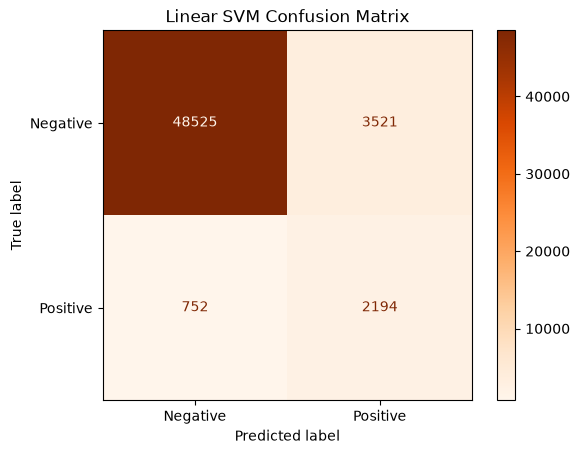

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    linear_svm_predictions,
    display_labels=[
        "Negative",
        "Positive"
    ],
    cmap="Oranges",
    values_format="d"
)

plt.title("Linear SVM Confusion Matrix")
plt.show()

In [ ]:
linear_svm_result = {
    "Model": "Linear SVM",
    "Accuracy": linear_svm_accuracy,
    "Precision": linear_svm_precision,
    "Recall": linear_svm_recall,
    "F1-score": linear_svm_f1,
    "Training Time": linear_svm_training_time
}

print(linear_svm_result)

{'Model': 'Linear SVM', 'Accuracy': 0.9222977887692755, 'Precision': 0.3839020122484689, 'Recall': 0.7447386286490156, 'F1-score': 0.5066389562406188, 'Training Time': 0.3090708255767822}


#### Interpretation of Linear SVM Results

The Linear SVM model achieved an accuracy of 92.23%, precision of 38.39%, recall of 74.47%, and F1-score of 50.66%. It correctly detected 2,194 positive cases but missed 752 positive cases. Although the model trained quickly, it produced 3,521 false-positive predictions, resulting in lower precision. Compared with Logistic Regression and Random Forest, Linear SVM produced the lowest accuracy, precision, and F1-score.

## Part 7: Model Comparison

The performances of Logistic Regression, Random Forest, and Linear SVM are compared using accuracy, precision, recall, F1-score, and training time. All models were trained and tested using the same dataset split to ensure a fair comparison.

In [ ]:
comparison_df = pd.DataFrame([
    logistic_result,
    random_forest_result,
    linear_svm_result
])

comparison_df = comparison_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time"
    ]
]

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "Training Time": "{:.2f} seconds"
    })
)

,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Logistic Regression,0.9276,0.4039,0.7393,0.5224,0.28 seconds
1,Random Forest,0.9282,0.4102,0.7756,0.5366,7.64 seconds
2,Linear SVM,0.9223,0.3839,0.7447,0.5066,0.31 seconds


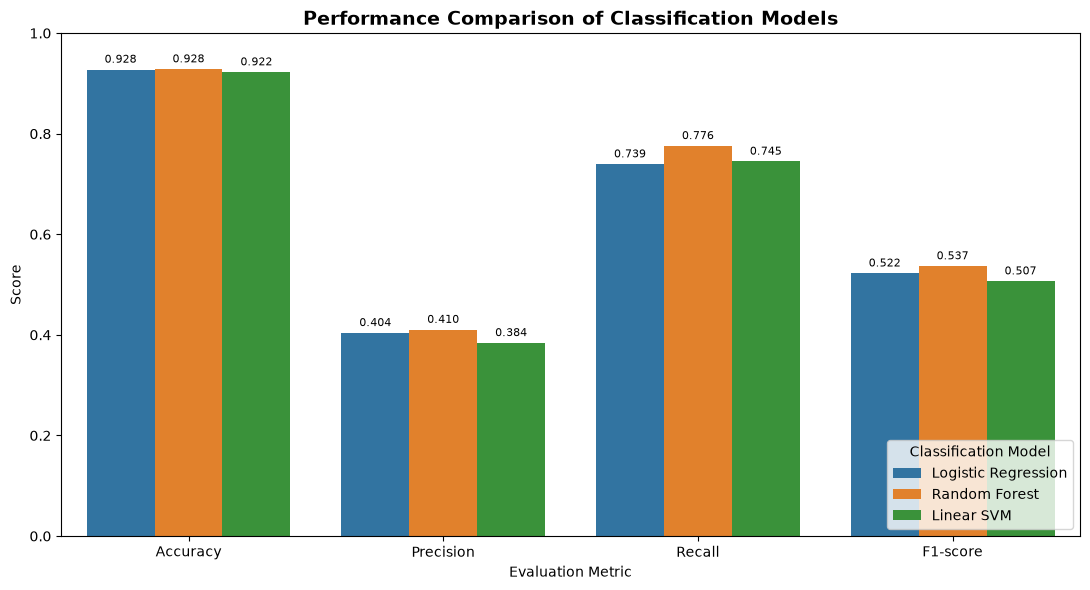

In [ ]:
metrics_for_chart = comparison_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

chart = sns.barplot(
    data=metrics_for_chart,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Performance Comparison of Classification Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

for container in chart.containers:
    chart.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=3
    )

plt.legend(
    title="Classification Model",
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [ ]:
best_model_row = comparison_df.loc[
    comparison_df["F1-score"].idxmax()
]

print("Best model based on F1-score:")
print(best_model_row)

Best model based on F1-score:
Model            Random Forest
Accuracy              0.928244
Precision             0.410233
Recall                0.775628
F1-score              0.536637
Training Time         7.636869
Name: 1, dtype: object


In [ ]:
for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]:
    best_index = comparison_df[metric].idxmax()

    print(
        f"Best {metric}:",
        comparison_df.loc[
            best_index,
            "Model"
        ],
        f"({comparison_df.loc[best_index, metric]:.4f})"
    )

Best Accuracy: Random Forest (0.9282)
Best Precision: Random Forest (0.4102)
Best Recall: Random Forest (0.7756)
Best F1-score: Random Forest (0.5366)


In [ ]:
comparison_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print(
    "Comparison results saved as "
    "model_comparison_results.csv"
)

Comparison results saved as model_comparison_results.csv


## Part 8: Best Model Saving and Deployment

Random Forest was selected as the best model based on its accuracy, precision, recall, and F1-score. The model and preprocessing component are saved together for integration with the Streamlit prototype.

In [ ]:
import joblib
from pathlib import Path

best_model_bundle = {
    "model_name": "Random Forest",
    "model": random_forest_model,
    "preprocessor": preprocessor,
    "metrics": {
        "Accuracy": random_forest_accuracy,
        "Precision": random_forest_precision,
        "Recall": random_forest_recall,
        "F1-score": random_forest_f1
    }
}

best_model_path = (
    Path.cwd() / "best_model_bundle.pkl"
)

joblib.dump(
    best_model_bundle,
    best_model_path
)

print("Best model saved successfully!")
print("Model: Random Forest")
print("Location:", best_model_path)

Best model saved successfully!
Model: Random Forest
Location: c:\Users\Leon\Documents\GitHub\COVID19_ML_Project\best_model_bundle.pkl


## Part 8: Saving All Classification Models

The three classification models and the shared preprocessing component are saved together. This allows the Streamlit prototype to run each group member's model and compare their predictions.

In [ ]:
import joblib
from pathlib import Path

all_models_bundle = {
    "preprocessor": preprocessor,

    "models": {
        "Logistic Regression": logistic_model,
        "Random Forest": random_forest_model,
        "Linear SVM": linear_svm_model
    },

    "metrics": {
        "Logistic Regression": {
            "Accuracy": logistic_accuracy,
            "Precision": logistic_precision,
            "Recall": logistic_recall,
            "F1-score": logistic_f1,
            "Training Time": logistic_training_time
        },

        "Random Forest": {
            "Accuracy": random_forest_accuracy,
            "Precision": random_forest_precision,
            "Recall": random_forest_recall,
            "F1-score": random_forest_f1,
            "Training Time": random_forest_training_time
        },

        "Linear SVM": {
            "Accuracy": linear_svm_accuracy,
            "Precision": linear_svm_precision,
            "Recall": linear_svm_recall,
            "F1-score": linear_svm_f1,
            "Training Time": linear_svm_training_time
        }
    },

    "best_model": "Random Forest"
}

In [ ]:
bundle_path = (
    Path.cwd() / "all_models_bundle.pkl"
)

joblib.dump(
    all_models_bundle,
    bundle_path
)

print("All models saved successfully!")
print("Saved location:", bundle_path)

All models saved successfully!
Saved location: c:\Users\Leon\Documents\GitHub\COVID19_ML_Project\all_models_bundle.pkl


In [ ]:
test_bundle = joblib.load(
    "all_models_bundle.pkl"
)

print("Available models:")

for model_name in test_bundle["models"]:
    print("-", model_name)

print(
    "\nBest-performing model:",
    test_bundle["best_model"]
)

Available models:
- Logistic Regression
- Random Forest
- Linear SVM

Best-performing model: Random Forest
